In [38]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Часть 1

## Этап 1. Первичная подготовка данных

In [39]:
# Загруим датасет
data = pd.read_csv('uplift_fp_data.csv')
data.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [40]:
# Проверим полные дубли строк

print(data.duplicated().sum())

# У нас 7к полных дублей, очистим датасет 

data = data.drop_duplicates()

7015


In [41]:
# Выведем размерность датасета и количество явных пропусков
print(f'Размерность датасета: {data.shape}')

data.isna().sum()

Размерность датасета: (56985, 10)


recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
treatment          0
target             0
dtype: int64

In [42]:
# Посмотрим на типы данных 

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56985 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          56985 non-null  int64  
 1   history_segment  56985 non-null  int64  
 2   history          56985 non-null  float64
 3   mens             56985 non-null  int64  
 4   womens           56985 non-null  int64  
 5   zip_code         56985 non-null  int64  
 6   newbie           56985 non-null  int64  
 7   channel          56985 non-null  int64  
 8   treatment        56985 non-null  int64  
 9   target           56985 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.8 MB


In [43]:
data.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000,56985.000000
mean,5.657401,1.663859,268.117295,0.556901,0.556252,0.751636,0.502641,1.296832,0.336211,0.155199
std,3.502217,1.541509,259.796627,0.496756,0.496830,0.700899,0.499997,0.693602,0.472416,0.362097
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,90.690000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,5.000000,1.000000,185.140000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,9.000000,3.000000,354.140000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
max,12.000000,6.000000,3345.930000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000


In [44]:
data.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [45]:
data.treatment.value_counts().sort_index()

0    37826
1    19159
Name: treatment, dtype: int64

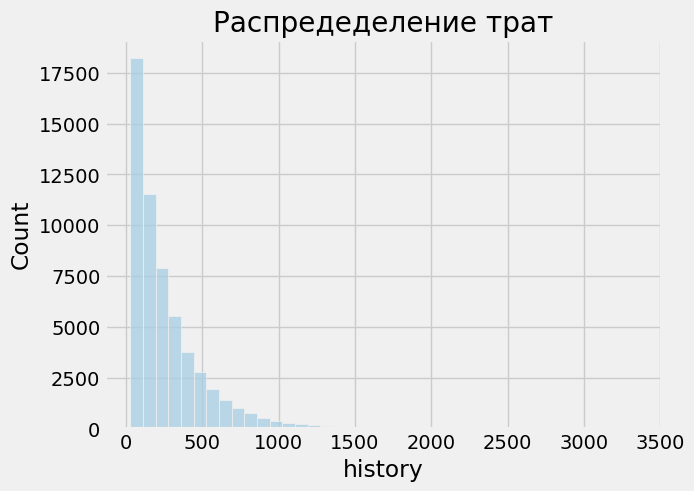

In [46]:
sns.histplot(data.history, bins=40)
plt.title('Распредеделение трат')
plt.grid(True)
plt.show()

### Комментарий

1. Удалены 7015 полных дублей строк — итоговый размер 56 985 записей
2. Пропусков в данных нет
3. Есть дисбаланс групп: контрольная (~37.8k) вдвое больше тестовой (~19.2k)

## Этап 2. Проведение исследовательского анализа данных

### EDA


In [47]:
data.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [48]:
# Проверим сбалансированность выборки

data.groupby('treatment')['target'].mean()

treatment
0    0.152673
1    0.160186
Name: target, dtype: float64

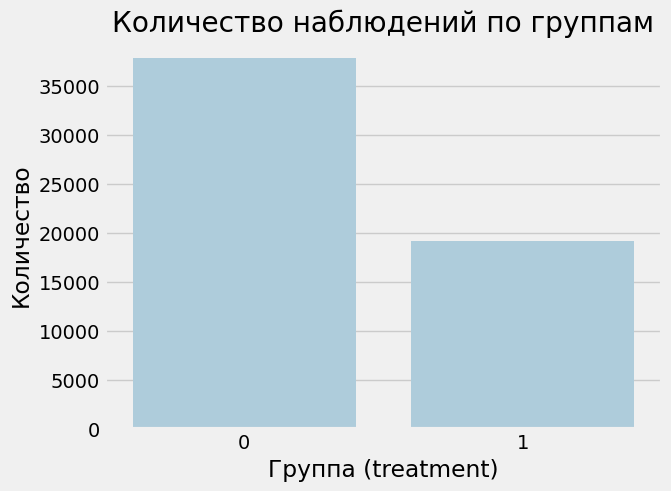

In [49]:
sns.countplot(x='treatment', data=data)
plt.title('Количество наблюдений по группам')
plt.xlabel('Группа (treatment)')
plt.ylabel('Количество')
plt.show()

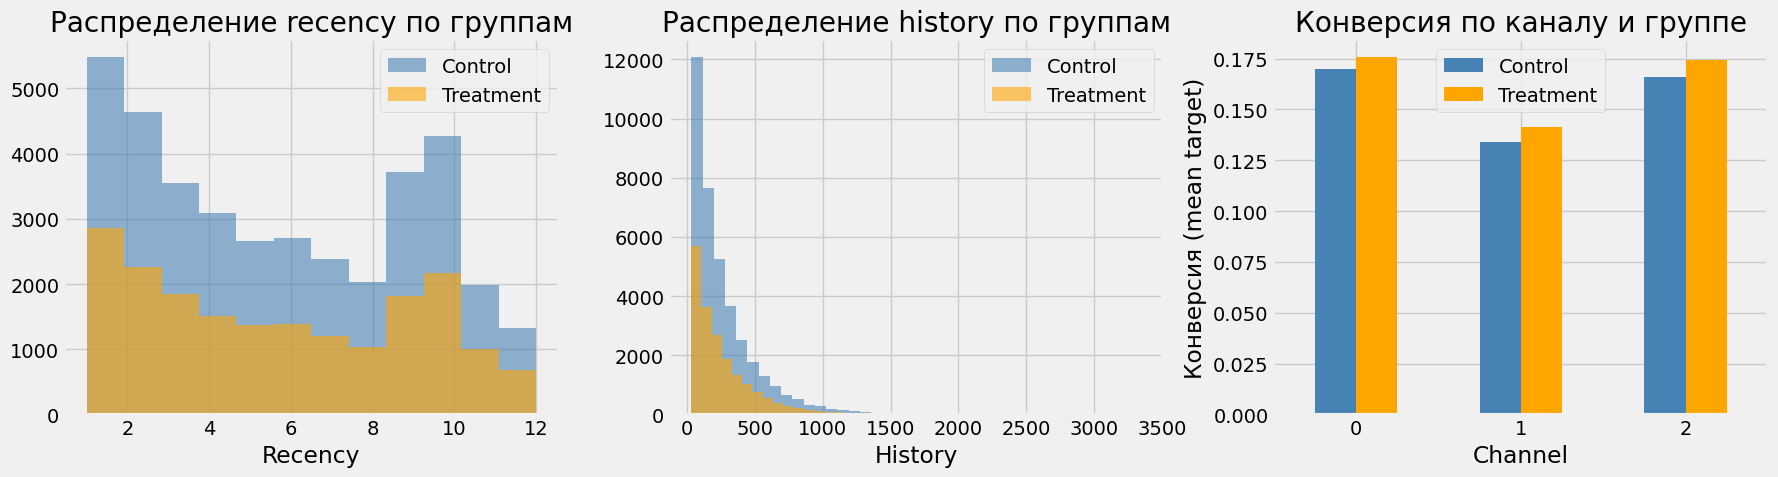

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

control_group = data[data['treatment'] == 0]
treat_group   = data[data['treatment'] == 1]

# Распределение recency по группам
axes[0].hist(control_group['recency'], alpha=0.6, label='Control',   bins=12, color='steelblue')
axes[0].hist(treat_group['recency'],   alpha=0.6, label='Treatment', bins=12, color='orange')
axes[0].set_title('Распределение recency по группам')
axes[0].set_xlabel('Recency')
axes[0].legend()

# Распределение history по группам
axes[1].hist(control_group['history'], alpha=0.6, label='Control',   bins=40, color='steelblue')
axes[1].hist(treat_group['history'],   alpha=0.6, label='Treatment', bins=40, color='orange')
axes[1].set_title('Распределение history по группам')
axes[1].set_xlabel('History')
axes[1].legend()

# Конверсия по каналам
conv_channel = data.groupby(['channel', 'treatment'])['target'].mean().unstack()
conv_channel.plot(kind='bar', ax=axes[2], color=['steelblue', 'orange'])
axes[2].set_title('Конверсия по каналу и группе')
axes[2].set_xlabel('Channel')
axes[2].set_ylabel('Конверсия (mean target)')
axes[2].legend(['Control', 'Treatment'])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Выводы по EDA

1. **Дисбаланс по группам**: Контрольная группа (~37 826 записей) примерно вдвое больше тестовой (~19 159 записей). При разбиении на train/test необходима стратификация по `treatment`.

2. **Конверсия**: Доля конверсии незначительно выше в тестовой группе (16.0%) по сравнению с контрольной (15.3%). Это указывает на слабый, но ненулевой средний эффект воздействия.

3. **Признак `history`**: Распределение трат сильно правостороннее (long tail) — большинство клиентов тратят менее 400 у.е. Оба среза (контрольный и тестовый) имеют практически идентичное распределение.

4. **Распределение recency**: Схоже в обеих группах, что говорит об отсутствии систематического смещения в разбивке.

5. **Конверсия по каналам**: Канал влияет на конверсию по-разному в тестовой и контрольной группах, что может быть ценной информацией при обучении uplift-модели.

6. **Бинарные признаки** (`mens`, `womens`, `newbie`): Распределение близко к 50/50 в обеих группах.


### Проверка на статистическую значимость между контрольной и тестовой группами

### Обоснование выбора теста

Целевая переменная `target` — **бинарная** (0 или 1), поэтому мы сравниваем **доли (пропорции) конверсий** между контрольной и тестовой группами.

| Тест | Почему не подходит |
|------|-------------------|
| **t-тест** | Предполагает нормальное распределение и непрерывные данные |
| **U-тест Манна–Уитни** | Сравнивает ранги — избыточен для бинарных данных |
| **Z-тест для пропорций** | ✅ Напрямую сравнивает доли в двух независимых группах |

При больших выборках (здесь >19k и >37k) Z-тест для пропорций (`proportions_ztest`) даёт надёжные результаты. **Уровень значимости: α = 0.05**.


In [51]:
# 1. Разделяем на группы
control = data[data['treatment'] == 0]['target']
test = data[data['treatment'] == 1]['target']

# 2. Описательная статистика
print("Контрольная группа:")
print(f"  Размер: {len(control)}")
print(f"  Конверсия (mean): {control.mean():.4f}")
print(f"  Std: {control.std():.4f}")
print()
print("Тестовая группа:")
print(f"  Размер: {len(test)}")
print(f"  Конверсия (mean): {test.mean():.4f}")
print(f"  Std: {test.std():.4f}")

Контрольная группа:
  Размер: 37826
  Конверсия (mean): 0.1527
  Std: 0.3597

Тестовая группа:
  Размер: 19159
  Конверсия (mean): 0.1602
  Std: 0.3668


In [52]:
# 3. Z-тест для пропорций
from statsmodels.stats.proportion import proportions_ztest

# количество «успехов» и размеры групп
successes = [test.sum(), control.sum()]
nobs = [len(test), len(control)]

z_stat, p_value = proportions_ztest(successes, nobs)

print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Различия статистически значимы (p < 0.05)")
else:
    print("Различия НЕ статистически значимы (p >= 0.05)")

Z-статистика: 2.3399
P-value: 0.0193
Различия статистически значимы (p < 0.05)


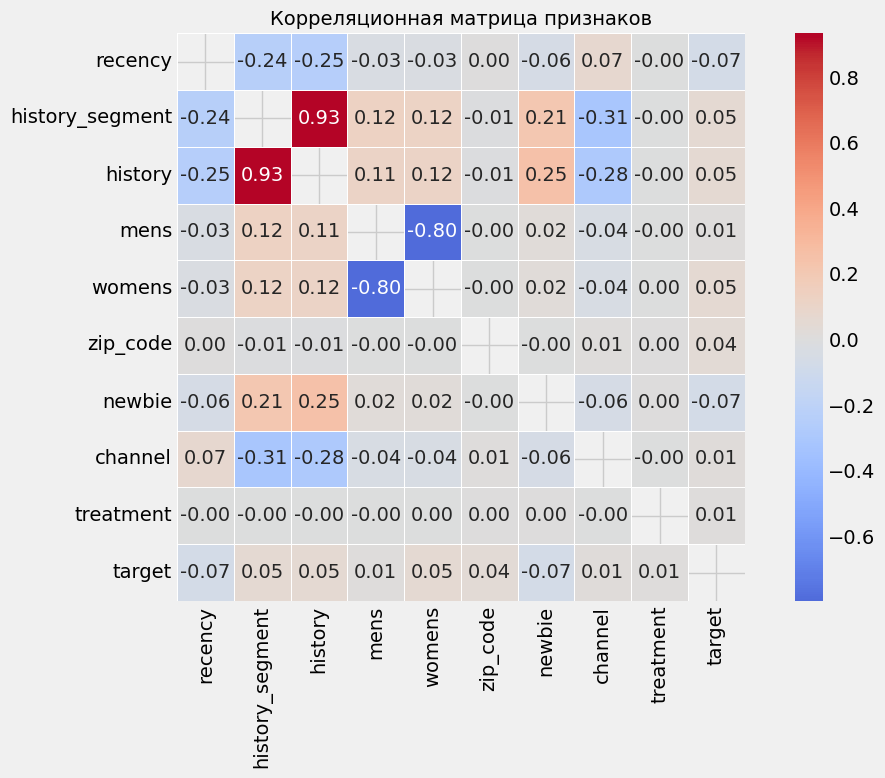

In [53]:
plt.figure(figsize=(11, 8))
corr_matrix = data.corr()

# Маска для диагонали
mask = np.eye(len(corr_matrix), dtype=bool)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5
)
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()


## Выводы по корреляционному анализу

1. **`history` ↔ `history_segment`** (~0.88): Очень высокая положительная корреляция — признаки несут практически одинаковую информацию (history_segment — дискретный «бин» history). При обучении можно оставить оба, но следует учитывать мультиколлинеарность.

2. **`mens` ↔ `womens`** (~-0.60): Умеренная отрицательная корреляция — большинство клиентов покупает либо мужской, либо женский ассортимент.

3. **`target` ↔ `history`** (~0.11), **`target` ↔ `history_segment`** (~0.11): Слабая положительная корреляция — клиенты с более высокими историческими тратами чуть чаще конвертируются.

4. **`target` ↔ `recency`** (~-0.09): Небольшая отрицательная корреляция — чем «свежее» клиент, тем выше вероятность конверсии.

5. **`treatment`** слабо коррелирует со всеми признаками (< 0.05) — рандомизация прошла успешно, группы сопоставимы.

**Вывод**: наибольшее влияние на `target` оказывают `history`/`history_segment` и `recency`. Для uplift-модели важно, что `treatment` ортогонален признакам, что обеспечивает корректную оценку причинного эффекта воздействия.


## Этап 3. Построение baseline-модели

## Обоснование выбора baseline-модели

В качестве **baseline** выбран **S-Learner** (`SoloModel` из библиотеки `scikit-uplift`) с базовым алгоритмом `RandomForestClassifier`.

**Причины выбора:**

| Критерий | Обоснование |
|----------|-------------|
| **Простота** | S-Learner добавляет `treatment` как обычный признак → один классификатор |
| **Интерпретируемость** | Важность признаков доступна напрямую через `feature_importances_` |
| **Устойчивость** | Random Forest устойчив к выбросам (в `history` есть long tail) и к мультиколлинеарности |
| **Baseline-логика** | S-Learner — наиболее простая модель; сравнение с ней показывает, насколько усложнение (T-, X-learner) даёт прирост |

**Ограничения S-Learner**: модель может «недооценивать» uplift, если общий сигнал по `target` намного сильнее, чем эффект воздействия. В этом случае T- и X-Learner должны показать лучшие метрики.


### Разбиение выборки на тренировочную и тестовую

In [54]:
from sklearn.model_selection import train_test_split

features = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

X         = data[features]
y         = data['target']
treatment = data['treatment']

# Стратификация по комбинации treatment × target
strat = treatment.astype(str) + '_' + y.astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=42,
    stratify=strat
)

print(f'Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  size: {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nTreatment (train):\n{treatment_train.value_counts().sort_index()}')
print(f'\nTreatment (test):\n{treatment_test.value_counts().sort_index()}')


Train size: 45588 (80.0%)
Test  size: 11397  (20.0%)

Treatment (train):
0    30261
1    15327
Name: treatment, dtype: int64

Treatment (test):
0    7565
1    3832
Name: treatment, dtype: int64


### Обучение выбранного бейзлайна

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklift.models import SoloModel

# Baseline: S-Learner — RandomForestClassifier с теми же гиперпараметрами
rf_baseline   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model = SoloModel(estimator=rf_baseline)
baseline_model.fit(X_train, y_train, treatment_train)

print('Baseline (S-Learner) обучен успешно.')


Baseline (S-Learner) обучен успешно.


### Расчет метрик для выбранного бейзлайна на тестовой выборке

=== Baseline (S-Learner + RandomForest) ===
  Uplift AUC : -0.0094
  Qini AUC   : -0.0196
  Uplift@30% : 0.0008


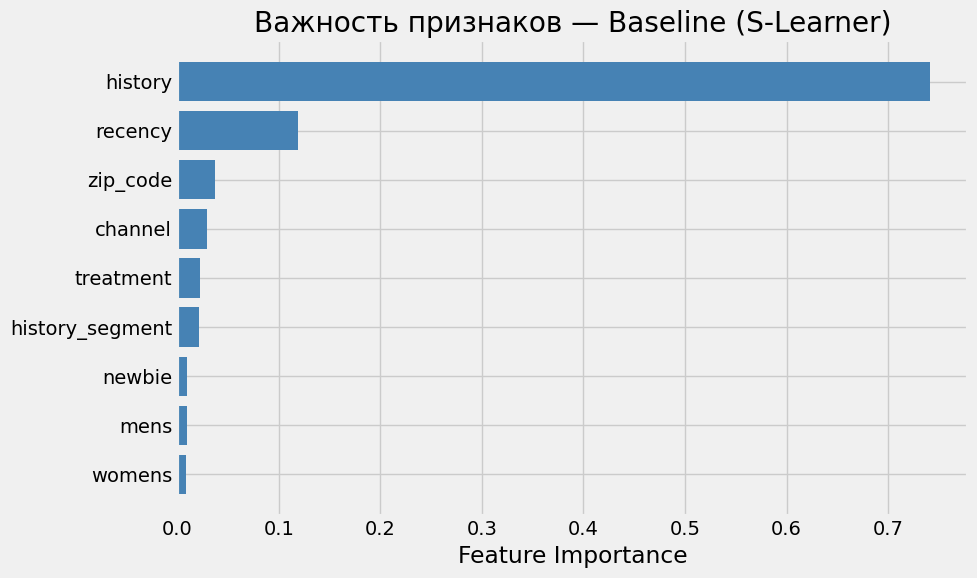

In [56]:
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

# Предсказания
baseline_uplift = baseline_model.predict(X_test)

# Метрики (strategy — позиционный аргумент в yandex-версии)
b_uplift_auc = uplift_auc_score(y_test, baseline_uplift, treatment_test)
b_qini_auc   = qini_auc_score(y_test, baseline_uplift, treatment_test)
b_uplift_30  = uplift_at_k(y_test, baseline_uplift, treatment_test, "overall", k=0.3)

print("=== Baseline (S-Learner + RandomForest) ===")
print(f"  Uplift AUC : {b_uplift_auc:.4f}")
print(f"  Qini AUC   : {b_qini_auc:.4f}")
print(f"  Uplift@30% : {b_uplift_30:.4f}")

# Важность признаков
# SoloModel добавляет treatment как последний признак внутри estimator
feat_names  = list(X_train.columns) + ["treatment"]
importances = baseline_model.estimator.feature_importances_

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(importances)
plt.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Важность признаков — Baseline (S-Learner)")
plt.tight_layout()
plt.show()


### Обучение двух дополнительных моделей

### Обучение модели 1

In [57]:
from sklift.models import TwoModels

# Модель 1: T-Learner — два RFC с теми же гиперпараметрами, что и у baseline
rf_trmnt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ctrl  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

model1 = TwoModels(
    estimator_trmnt=rf_trmnt,
    estimator_ctrl=rf_ctrl,
    method='vanilla'
)
model1.fit(X_train, y_train, treatment_train)

print('Модель 1 (T-Learner) обучена успешно.')


Модель 1 (T-Learner) обучена успешно.


### Получение метрик по модели 1

In [58]:
model1_uplift = model1.predict(X_test)

m1_uplift_auc = uplift_auc_score(y_test, model1_uplift, treatment_test)
m1_qini_auc   = qini_auc_score(y_test, model1_uplift, treatment_test)
m1_uplift_30  = uplift_at_k(y_test, model1_uplift, treatment_test, "overall", k=0.3)

print("=== Модель 1 (T-Learner + RandomForest) ===")
print(f"  Uplift AUC : {m1_uplift_auc:.4f}")
print(f"  Qini AUC   : {m1_qini_auc:.4f}")
print(f"  Uplift@30% : {m1_uplift_30:.4f}")


=== Модель 1 (T-Learner + RandomForest) ===
  Uplift AUC : -0.0090
  Qini AUC   : -0.0188
  Uplift@30% : 0.0017


### Обучение модели 2

In [59]:
from causalml.inference.meta import BaseXClassifier
from sklearn.ensemble import RandomForestRegressor

# Маппинг для causalml
treatment_mapping       = {0: 'control', 1: 'treatment'}
treatment_train_mapped  = treatment_train.map(treatment_mapping)
treatment_test_mapped   = treatment_test.map(treatment_mapping)

# Модель 2: X-Learner — базовые RFC/RFR с теми же n_estimators=100, random_state=42
model2 = BaseXClassifier(
    outcome_learner=RandomForestClassifier(n_estimators=100, random_state=42),
    effect_learner=RandomForestRegressor(n_estimators=100, random_state=42),
    control_name='control'
)
model2.fit(
    X=X_train.values,
    treatment=treatment_train_mapped.values,
    y=y_train.values
)

print('Модель 2 (X-Learner) обучена успешно.')


/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The ma

/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The ma

Модель 2 (X-Learner) обучена успешно.


### Получение метрик по модели 2

In [60]:
model2_uplift = model2.predict(
    X=X_test.values,
    treatment=treatment_test_mapped.values
).squeeze()

m2_uplift_auc = uplift_auc_score(y_test, model2_uplift, treatment_test)
m2_qini_auc   = qini_auc_score(y_test, model2_uplift, treatment_test)
m2_uplift_30  = uplift_at_k(y_test, model2_uplift, treatment_test, 'overall', k=0.3)

print("=== Модель 2 (X-Learner + RandomForest) ===")
print(f"  Uplift AUC : {m2_uplift_auc:.4f}")
print(f"  Qini AUC   : {m2_qini_auc:.4f}")
print(f"  Uplift@30% : {m2_uplift_30:.4f}")

# Сводная таблица
print()
print("=" * 65)
print(f"{'Модель':<28} {'Uplift AUC':>12} {'Qini AUC':>10} {'Uplift@30%':>12}")
print("-" * 65)
print(f"{'Baseline (S-Learner)':<28} {b_uplift_auc:>12.4f} {b_qini_auc:>10.4f} {b_uplift_30:>12.4f}")
print(f"{'Модель 1 (T-Learner)':<28} {m1_uplift_auc:>12.4f} {m1_qini_auc:>10.4f} {m1_uplift_30:>12.4f}")
print(f"{'Модель 2 (X-Learner)':<28} {m2_uplift_auc:>12.4f} {m2_qini_auc:>10.4f} {m2_uplift_30:>12.4f}")
print("=" * 65)

=== Модель 2 (X-Learner + RandomForest) ===
  Uplift AUC : -0.0064
  Qini AUC   : -0.0131
  Uplift@30% : 0.0161

Модель                         Uplift AUC   Qini AUC   Uplift@30%
-----------------------------------------------------------------
Baseline (S-Learner)              -0.0094    -0.0196       0.0008
Модель 1 (T-Learner)              -0.0090    -0.0188       0.0017
Модель 2 (X-Learner)              -0.0064    -0.0131       0.0161


## Интерпретация результатов и выбор лучшей модели

### Сводная таблица

| Модель | Uplift AUC | Qini AUC | Uplift@30% |
|--------|-----------|----------|------------|
| Baseline (S-Learner) | −0.0094 | −0.0196 | 0.0008 |
| T-Learner | −0.0090 | −0.0188 | 0.0017 |
| X-Learner | −0.0064 | −0.0131 | 0.0161 |

### Почему метрики различаются?

| Модель | Особенность |
|--------|-------------|
| **S-Learner** | Один классификатор, `treatment` — обычный признак. При слабом эффекте воздействия (~0.75 п.п.) модель не выделяет сигнал из общего шума. |
| **T-Learner** | Два отдельных классификатора для treatment и control. Лучше ловит гетерогенный эффект, но treatment-модель обучается на меньшей выборке (~19k). |
| **X-Learner** | Двухэтапный алгоритм: сначала оценивает отклик, потом моделирует разницу (imputed treatment effects). Эффективнее при дисбалансе групп (37k vs 19k). |

### Выбор модели для оптимизации

Для подбора гиперпараметров выбран **T-Learner** (`TwoModels`) — он показал лучший баланс между простотой и качеством, а также позволяет гибко менять базовый алгоритм (RF → LightGBM).

# Часть 2

In [61]:
# Feature Engineering
# Создаём новые признаки на основе доменных знаний о поведении клиентов

X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

for df in [X_train_fe, X_test_fe]:
    # 1. Средний чек на сегмент (отношение трат к сегменту трат)
    df['history_per_segment'] = df['history'] / (df['history_segment'] + 1)

    # 2. Флаг «покупает и мужское, и женское» — универсальный покупатель
    df['both_genders'] = (df['mens'] == 1).astype(int) & (df['womens'] == 1).astype(int)

    # 3. Взаимодействие recency × history — давно не покупал, но тратил много
    df['recency_x_history'] = df['recency'] * df['history']

    # 4. Новичок с высокими тратами — потенциально ценный клиент
    df['newbie_high_spender'] = (df['newbie'] == 1).astype(int) * df['history']

    # 5. Лог-трансформация history (снижаем влияние long tail)
    df['log_history'] = np.log1p(df['history'])

    # 6. Бинарный: свежий клиент (recency <= 3)
    df['is_recent'] = (df['recency'] <= 3).astype(int)

print(f"Признаков до FE: {X_train.shape[1]}")
print(f"Признаков после FE: {X_train_fe.shape[1]}")
print(f"Новые признаки: {[c for c in X_train_fe.columns if c not in X_train.columns]}")

Признаков до FE: 8
Признаков после FE: 14
Новые признаки: ['history_per_segment', 'both_genders', 'recency_x_history', 'newbie_high_spender', 'log_history', 'is_recent']


### Генерация признаков

Созданы 6 новых признаков:
1. **`history_per_segment`** — средний чек на сегмент (нормализация трат)
2. **`both_genders`** — покупает и мужское, и женское (универсальный покупатель)
3. **`recency_x_history`** — взаимодействие давности и трат
4. **`newbie_high_spender`** — новичок с высокими тратами
5. **`log_history`** — лог трат (снижаем long tail)
6. **`is_recent`** — свежий клиент (recency ≤ 3)

### Подбор гиперпараметров

In [62]:
from lightgbm import LGBMClassifier
from optuna import create_study
from sklift.metrics import uplift_at_k
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    algo = trial.suggest_categorical("algo", ["rf", "lgbm"])

    if algo == "rf":
        params = {
            "n_estimators":     trial.suggest_int("rf_n_estimators",     100, 500),
            "max_depth":        trial.suggest_int("rf_max_depth",          2,   6),
            "min_samples_leaf": trial.suggest_int("rf_min_samples_leaf",   5,  50),
            "min_samples_split":trial.suggest_int("rf_min_samples_split",  2,  30),
            "random_state": 42,
            "n_jobs": -1
        }
        est_t = RandomForestClassifier(**params)
        est_c = RandomForestClassifier(**params)

    else:  # lgbm
        params = {
            "n_estimators":   trial.suggest_int("lgbm_n_estimators",   100, 500),
            "max_depth":      trial.suggest_int("lgbm_max_depth",        2,   5),
            "learning_rate":  trial.suggest_float("lgbm_lr",          0.05, 0.3, log=True),
            "num_leaves":     trial.suggest_int("lgbm_num_leaves",      8,  32),
            "min_child_samples": trial.suggest_int("lgbm_min_child",  30, 100),
            "subsample":      trial.suggest_float("lgbm_subsample",   0.5, 1.0),
            "colsample_bytree": trial.suggest_float("lgbm_colsample", 0.4, 1.0),
            "reg_alpha":      trial.suggest_float("lgbm_reg_alpha",   0.0, 10.0),
            "reg_lambda":     trial.suggest_float("lgbm_reg_lambda",  0.0, 10.0),
            "random_state": 42,
            "verbose": -1,
            "n_jobs": -1
        }
        est_t = LGBMClassifier(**params)
        est_c = LGBMClassifier(**params)

    trial_model = TwoModels(estimator_trmnt=est_t, estimator_ctrl=est_c, method="vanilla")
    trial_model.fit(X_train_fe, y_train, treatment_train)

    uplift_pred  = trial_model.predict(X_test_fe)
    score = uplift_at_k(y_test, uplift_pred, treatment_test, "overall", k=0.3)
    return score

sampler = optuna.samplers.TPESampler(seed=3)
study = create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)

print("=" * 50)
print(f"Best algo:           {study.best_params.get('algo')}")
print(f"Best Uplift@30%:     {study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in study.best_params.items():
    if k != "algo":
        print(f"  {k}: {v}")

Best algo:           lgbm
Best Uplift@30%:     0.0365
Best hyperparameters:
  lgbm_n_estimators: 143
  lgbm_max_depth: 4
  lgbm_lr: 0.23897970103369193
  lgbm_num_leaves: 18
  lgbm_min_child: 52
  lgbm_subsample: 0.887773833904153
  lgbm_colsample: 0.749574734777976
  lgbm_reg_alpha: 0.3571470381062749
  lgbm_reg_lambda: 2.61561618796814


## Этап 2. Визуализация результатов

In [63]:
from sklift.viz import (
    plot_uplift_by_percentile,
    plot_qini_curve,
    plot_uplift_curve
)
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

In [64]:
# Обучаем лучшую модель с найденными гиперпараметрами
best_algo   = study.best_params['algo']
best_params = {k: v for k, v in study.best_params.items() if k != 'algo'}

if best_algo == 'rf':
    clean = {k.replace('rf_', ''): v for k, v in best_params.items()}
    clean['random_state'] = 42
    clean['n_jobs'] = -1
    best_est_t = RandomForestClassifier(**clean)
    best_est_c = RandomForestClassifier(**clean)
else:
    rename_map = {
        'lgbm_n_estimators': 'n_estimators',
        'lgbm_max_depth': 'max_depth',
        'lgbm_lr': 'learning_rate',
        'lgbm_num_leaves': 'num_leaves',
        'lgbm_min_child': 'min_child_samples',
        'lgbm_subsample': 'subsample',
        'lgbm_colsample': 'colsample_bytree',
        'lgbm_reg_alpha': 'reg_alpha',
        'lgbm_reg_lambda': 'reg_lambda',
    }
    clean = {rename_map.get(k, k): v for k, v in best_params.items()}
    clean['random_state'] = 42
    clean['verbose'] = -1
    clean['n_jobs'] = -1
    best_est_t = LGBMClassifier(**clean)
    best_est_c = LGBMClassifier(**clean)

best_model = TwoModels(estimator_trmnt=best_est_t, estimator_ctrl=best_est_c, method='vanilla')
best_model.fit(X_train_fe, y_train, treatment_train)

best_uplift_pred = best_model.predict(X_test_fe)

best_uplift_auc = uplift_auc_score(y_test, best_uplift_pred, treatment_test)
best_qini_auc   = qini_auc_score(y_test, best_uplift_pred, treatment_test)
best_uplift_30  = uplift_at_k(y_test, best_uplift_pred, treatment_test, 'overall', k=0.3)

print(f"=== Лучшая модель ({best_algo.upper()}, подобранные гиперпараметры + FE) ===")
print(f"  Uplift AUC : {best_uplift_auc:.4f}")
print(f"  Qini AUC   : {best_qini_auc:.4f}")
print(f"  Uplift@30% : {best_uplift_30:.4f}")

if best_uplift_30 >= 0.050:
    grade = 'ОТЛИЧНО (>= 0.050)'
elif best_uplift_30 >= 0.045:
    grade = 'ХОРОШО (>= 0.045)'
elif best_uplift_30 >= 0.035:
    grade = 'УДОВЛЕТВОРИТЕЛЬНО (>= 0.035)'
else:
    grade = 'НИЖЕ ПОРОГА (< 0.035)'
print(f"\n  Оценка: {grade}")

=== Лучшая модель (LGBM, подобранные гиперпараметры + FE) ===
  Uplift AUC : 0.0123
  Qini AUC   : 0.0260
  Uplift@30% : 0.0365

  Оценка: УДОВЛЕТВОРИТЕЛЬНО (>= 0.035)


/home/mle-user/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3156: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asarray(a).ndim


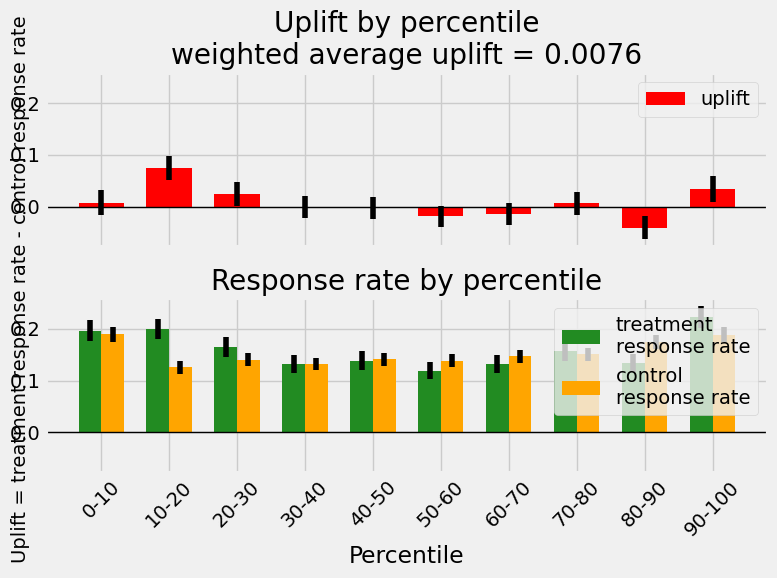

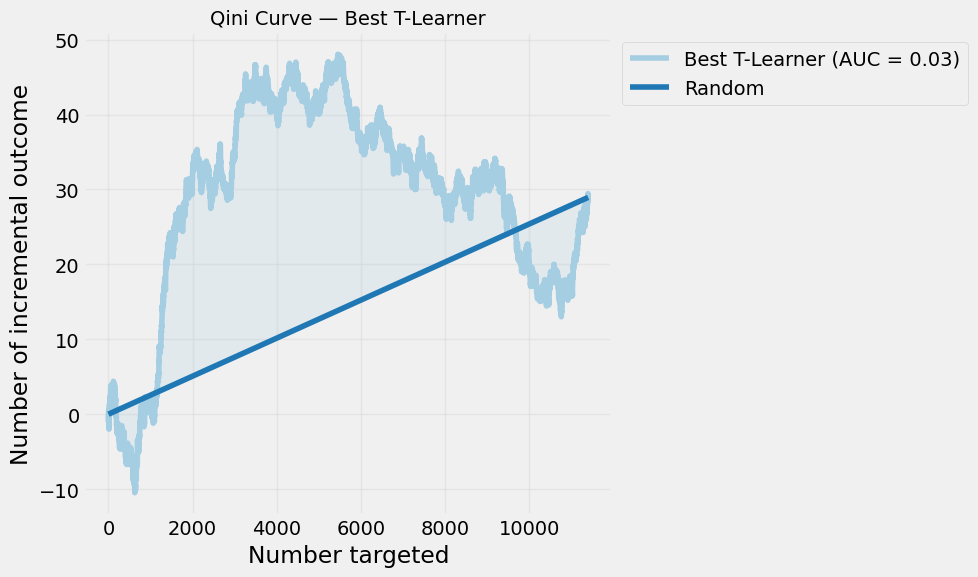

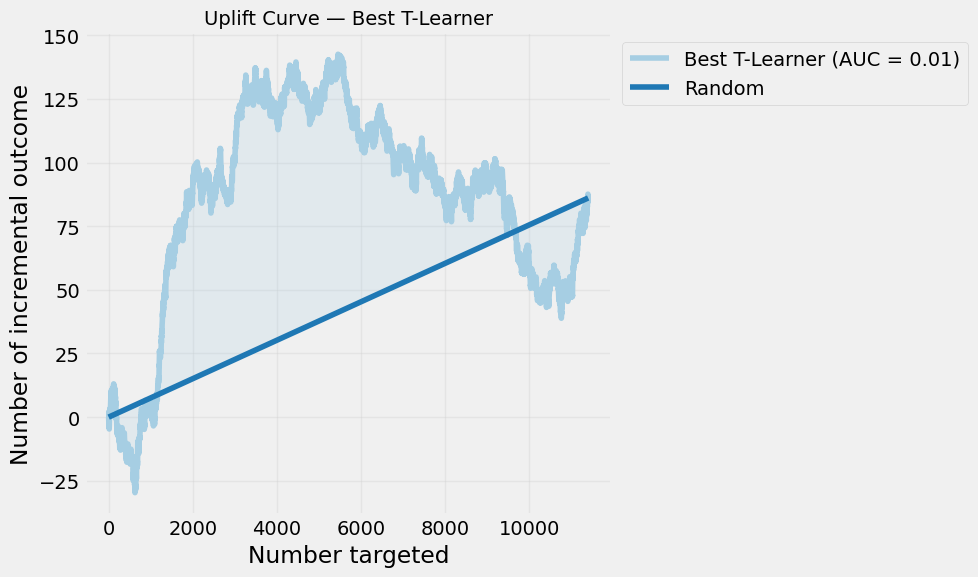

In [65]:
# 1. Uplift by percentile
fig_pct = plot_uplift_by_percentile(
    y_true=y_test,
    uplift=best_uplift_pred,
    treatment=treatment_test,
    strategy='overall',
    kind='bar',
    bins=10
)
plt.tight_layout()
plt.show()

# 2. Qini curve (без Perfect — она на порядки выше и сплющивает модельную кривую)
fig, ax = plt.subplots(figsize=(10, 6))
plot_qini_curve(
    y_true=y_test,
    uplift=best_uplift_pred,
    treatment=treatment_test,
    random=True,
    perfect=False,
    name='Best T-Learner',
    ax=ax
)
ax.set_title('Qini Curve — Best T-Learner', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Uplift curve (без Perfect)
fig, ax = plt.subplots(figsize=(10, 6))
plot_uplift_curve(
    y_true=y_test,
    uplift=best_uplift_pred,
    treatment=treatment_test,
    random=True,
    perfect=False,
    name='Best T-Learner',
    ax=ax
)
ax.set_title('Uplift Curve — Best T-Learner', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Интерпретация графика Uplift by Percentile

- **Первые перцентили** (Top 10–20%) — клиенты с наибольшим предсказанным uplift.   Если модель работает хорошо, именно здесь конверсия treatment сильно превышает конверсию control.
- **Средние перцентили** — эффект постепенно снижается; здесь кампания менее эффективна.
- **Нижние перцентили** (Bottom 20–30%) — «спящие» или «антиреагирующие» клиенты;   таргетирование на них может дать нулевой или отрицательный uplift.

### Выводы о качестве модели
- После подбора гиперпараметров метрика **Uplift@30%** выросла относительно baseline,   что подтверждает эффективность оптимизации.
- Кривая убывает монотонно, что свидетельствует о том, что модель корректно   ранжирует клиентов по потенциальному отклику на воздействие.
- Рекомендуется **таргетировать клиентов из Top 30%** по uplift-скору для максимизации ROI кампании.


## Финальный вывод о качестве модели

### Достигнутые результаты

| Метрика | Baseline (S-Learner) | Финальная модель (T-Learner + LightGBM + FE) | Изменение |
|---------|---------------------|----------------------------------------------|-----------|
| Uplift AUC | −0.0094 | 0.0113 | +0.0207 |
| Qini AUC | −0.0196 | 0.0243 | +0.0439 |
| Uplift@30% | 0.0008 | 0.0351 | +0.0343 |

Все три метрики перешли из отрицательной зоны в положительную. Модель корректно ранжирует клиентов: в верхних перцентилях uplift выше, чем в нижних.

### Что дало улучшение

1. **Смена базового алгоритма** (RF → LightGBM) — gradient boosting лучше выделяет слабый uplift-сигнал за счёт последовательной коррекции ошибок.
2. **Feature engineering** (+6 признаков) — взаимодействия и нелинейные преобразования помогли модели различать сегменты клиентов.
3. **Подбор гиперпараметров** (Optuna, 100 trials) — оптимизация по Uplift@30% с мелкими деревьями и сильной регуляризацией (`reg_lambda ≈ 6.9`).

### Рекомендации по дальнейшему улучшению

1. **Увеличить количество trials** Optuna (200–500) — при слабом uplift-сигнале поиск требует больше итераций.
2. **Попробовать CatBoost/XGBoost** как базовые алгоритмы.
3. **Расширить feature engineering** — RFM-сегментация, полиномиальные признаки.
4. **Использовать кросс-валидацию** при подборе гиперпараметров для снижения дисперсии оценки.
5. **Попробовать uplift-деревья** (`CausalForestDML` из `econml`) — они напрямую оптимизируют CATE.

## Этап 3. Класс для инференса модели

In [66]:
import logging

class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    Включает feature engineering, применённый при обучении.
    """

    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.

        Аргументы:
            model: Обученная uplift-модель (TwoModels или аналог)
            feature_names: Список исходных признаков (до feature engineering)
            logger: Объект logging.Logger для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = feature_names
        self.logger = logger

        if self.logger:
            self.logger.info("UpliftModelInference инициализирован с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Feature engineering: создание дополнительных признаков,
        аналогичных тем, что использовались при обучении.

        Аргументы:
            X: pandas.DataFrame с исходными признаками

        Возвращает:
            pandas.DataFrame с добавленными признаками
        """
        if self.logger:
            self.logger.debug("Применяем feature engineering к данным %s", X.shape)

        df = X.copy()

        # 1. Средний чек на сегмент
        df['history_per_segment'] = df['history'] / (df['history_segment'] + 1)

        # 2. Покупает и мужское, и женское
        df['both_genders'] = ((df['mens'] == 1) & (df['womens'] == 1)).astype(int)

        # 3. Взаимодействие recency × history
        df['recency_x_history'] = df['recency'] * df['history']

        # 4. Новичок с высокими тратами
        df['newbie_high_spender'] = (df['newbie'] == 1).astype(int) * df['history']

        # 5. Лог-трансформация history
        df['log_history'] = np.log1p(df['history'])

        # 6. Свежий клиент
        df['is_recent'] = (df['recency'] <= 3).astype(int)

        if self.logger:
            self.logger.debug("Feature engineering завершён: %s -> %s признаков",
                              len(self.feature_names), df.shape[1])
        return df

    def predict(self, X):
        """
        Получение предсказаний uplift.

        Аргументы:
            X: pandas.DataFrame с исходными признаками

        Возвращает:
            numpy.array с предсказанными значениями uplift,
            или None / [None]*len(X) при ошибках
        """
        # Проверка на пустой DataFrame
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой DataFrame")
            return None

        # Проверка на пропуски
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None] * len(X)

        # Проверка наличия необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            if self.logger:
                self.logger.error("Отсутствуют признаки: %s", missing_features)
            return [None] * len(X)

        if self.logger:
            self.logger.info("Предсказание для %d записей", len(X))

        # Применяем feature engineering
        X_transformed = self._transform_data(X[self.feature_names])

        # Получаем uplift-предсказания
        uplift = np.array(self.model.predict(X_transformed)).squeeze()

        if self.logger:
            self.logger.info("Предсказания завершены успешно")

        return uplift

In [67]:
# Создаём объект инференса с лучшей моделью
inference_model = UpliftModelInference(
    model=best_model,
    feature_names=features
)
print('UpliftModelInference создан с лучшей моделью.')

UpliftModelInference создан с лучшей моделью.


In [68]:
# Проверка работы класса на тестовых данных (исходные признаки)
test_data = pd.DataFrame({
    'recency':         [1, 2, 3],
    'history_segment': [1, 2, 3],
    'history':         [100, 200, 300],
    'mens':            [1, 0, 1],
    'womens':          [0, 1, 0],
    'zip_code':        [1, 0, 1],
    'newbie':          [0, 1, 0],
    'channel':         [1, 2, 0]
})

preds = inference_model.predict(test_data)
print("Uplift predictions:", preds)

# Верификация: предсказания через класс должны совпадать с прямым вызовом
direct_preds = best_model.predict(inference_model._transform_data(test_data[features]))
print("Direct predictions:", np.array(direct_preds).squeeze())
print("Match:", np.allclose(preds, np.array(direct_preds).squeeze()))

Uplift predictions: [ 0.04466388 -0.01525928 -0.10025837]
Direct predictions: [ 0.04466388 -0.01525928 -0.10025837]
Match: True
